n = 500
Paired t‑test: t = -1.3514, p = 0.1772
Mean difference = -0.9765 (SD = 16.16), 95% CI = [-2.396, 0.4432]
Cohen's d (paired) = -0.06044
Shapiro‑Wilk on differences: p = 0.001768
Significant difference (α = 0.05):
No


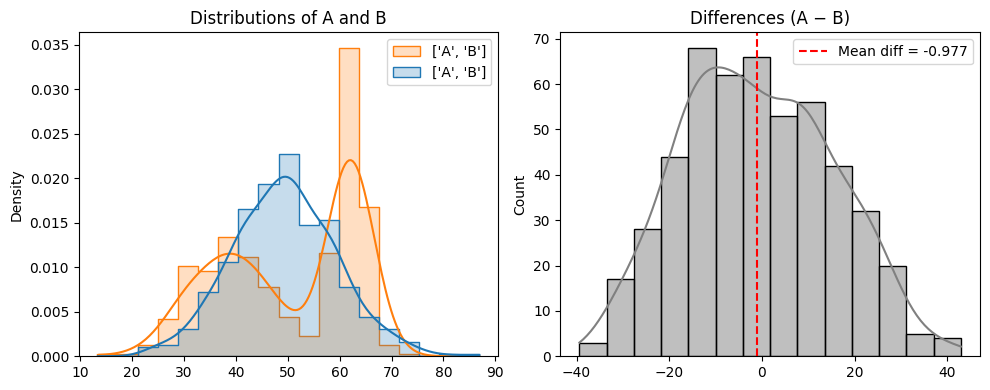

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# -------------------- Parameters --------------------
INPUT_PATH = Path("input_data/data.csv")
OUTPUT_PATH = Path("/display_output/final_result.txt")
ALPHA = 0.05
# ----------------------------------------------------

# ---------- Load & validate ----------
if not INPUT_PATH.is_file():
    raise FileNotFoundError(f"Input file not found: {INPUT_PATH}")

df = pd.read_csv(INPUT_PATH)

for col in ("A", "B"):
    if col not in df.columns:
        raise KeyError(f"Column '{col}' missing in input data")

# coerce to numeric, drop any pair with NaN
df["A"] = pd.to_numeric(df["A"], errors="coerce")
df["B"] = pd.to_numeric(df["B"], errors="coerce")
df = df.dropna(subset=["A", "B"]).reset_index(drop=True)

n = len(df)
if n == 0:
    raise ValueError("No valid paired observations after cleaning")

a = df["A"].values
b = df["B"].values
diff = a - b

# ---------- Descriptive stats ----------
mean_diff = diff.mean()
sd_diff = diff.std(ddof=1)
se_diff = sd_diff / np.sqrt(n)

t_stat, p_val = stats.ttest_rel(a, b)

# 95% CI for mean difference
t_crit = stats.t.ppf(1 - ALPHA / 2, df=n - 1)
ci_lower = mean_diff - t_crit * se_diff
ci_upper = mean_diff + t_crit * se_diff

# Cohen's d for paired samples
cohen_d = mean_diff / sd_diff if sd_diff != 0 else np.nan

# ---------- Normality & alternative test ----------
normality_p = None
if n <= 5000:                      # Shapiro‑Wilk limit
    _, normality_p = stats.shapiro(diff)

use_wilcoxon = False
wilcoxon_res = None
if normality_p is not None and normality_p < 0.05 and n < 50:
    use_wilcoxon = True
    wilcoxon_res = stats.wilcoxon(a, b)

# ---------- Decision ----------
significant = "Yes" if p_val < ALPHA else "No"
if use_wilcoxon and wilcoxon_res is not None:
    significant = "Yes" if wilcoxon_res.pvalue < ALPHA else "No"

# ---------- Output ----------
print(f"n = {n}")
print(f"Paired t‑test: t = {t_stat:.4f}, p = {p_val:.4g}")
print(
    f"Mean difference = {mean_diff:.4g} (SD = {sd_diff:.4g}), "
    f"95% CI = [{ci_lower:.4g}, {ci_upper:.4g}]"
)
print(f"Cohen's d (paired) = {cohen_d:.4g}")
if normality_p is not None:
    print(f"Shapiro‑Wilk on differences: p = {normality_p:.4g}")
if use_wilcoxon and wilcoxon_res is not None:
    print(
        f"Wilcoxon signed‑rank: statistic = {wilcoxon_res.statistic}, "
        f"p = {wilcoxon_res.pvalue:.4g}"
    )

# second‑last print – description of the result
print(f"Significant difference (α = {ALPHA}):")
# final print – only the Yes/No answer
print(significant)

# write final Yes/No answer
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
with open(OUTPUT_PATH, "w") as fp:
    fp.write(significant)

# ---------- Optional visualisation ----------
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot([a, b], kde=True, stat="density", element="step", label=["A", "B"])
plt.legend()
plt.title("Distributions of A and B")

plt.subplot(1, 2, 2)
sns.histplot(diff, kde=True, color="gray")
plt.axvline(mean_diff, color="red", linestyle="--", label=f"Mean diff = {mean_diff:.3g}")
plt.title("Differences (A − B)")
plt.legend()
plt.tight_layout()
plt.show()
